In [253]:
import sys
import os
sys.path.append(os.path.abspath('..')) #for accesing folder

In [293]:
import pandas as pd
import numpy as np
import torch
import transformers
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

#print(f"PyTorch version: {torch.__version__}")

In [297]:
#loading Train.csv dataset
train_df = pd.read_csv('../dataset/Train.csv', engine='python', encoding='utf-8')#python engine for not getting error - long message about C engine
train_df.reset_index(drop=True) #resetting index to start from 0
train_df.head(5)

#loading Validation.csv dataset
val_df = pd.read_csv('../dataset/Validation.csv', engine='python', encoding='utf-8')
val_df.reset_index(drop=True)
val_df.head(5)

#loading Validation.csv dataset
test_df = pd.read_csv('../dataset/Test.csv', engine='python', encoding='utf-8')
test_df.reset_index(drop=True)
test_df.head(5)

,Query,Label
0,A pretentious but - to varying degrees - watch...,0.0
1,Tamar-Mattis said organization supports Austr...,0.0
2,5337,0.0
3,SELECT * FROM nothing WHERE quick NOT LIKE '[s...,0.0
4,SELECT TOP 50 PERCENT * FROM according SELECT ...,0.0


In [298]:
train_df.shape #(98085, 2) - 98085 rows and 2 columns (query and label)
train_df.columns.to_list() #['Query', 'Label'] - columns names
train_df['Label'].value_counts()
#0 (non-SQLi) - 51377
#1 (SQLi) - 46685

Label
0.0    51377
1.0    46685
Name: count, dtype: int64

In [299]:
train_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access
val_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access
#train_df.columns.to_list()

#removing NaN values
train_df = train_df.dropna()
val_df = val_df.dropna()

#label setting as int values
train_df['label'] = train_df['label'].astype(int)
val_df['label'] = val_df['label'].astype(int)
train_df.head(5)

train_df.reset_index(drop=True) #resetting index to start from 0
val_df.reset_index(drop=True) #resetting index to start from 0

#train_df[train_df['label'] == 1].head(3) #first 3 SQLi queries

,query,label
0,Genius or utter madness? That depends on your ...,0
1,Most who go to this movie will have an idea wh...,0
2,SELECT safe ( s ) FROM stranger,0
3,"SELECT Orders.knownrID, Employees.whale, Emp...",0
4,9999999999999999999999999999999999999999999999...,1
...,...,...
32682,This is one seriously disturbed movie. Even Th...,1
32683,1' ) or 7552 = ( select count ( * ) from rd...,1
32684,1 ) as eryo where 2531 = 2531 rlike sleep...,1
32685,9185,0


In [300]:
test_df.columns = ['query', 'label'] #renaming columns to lowercase for easier access

#removing NaN values
test_df = test_df.dropna()

#label setting as int values
test_df['label'] = test_df['label'].astype(int)

test_df.reset_index(drop=True) #resetting index to start from 0

,query,label
0,A pretentious but - to varying degrees - watch...,0
1,Tamar-Mattis said organization supports Austr...,0
2,5337,0
3,SELECT * FROM nothing WHERE quick NOT LIKE '[s...,0
4,SELECT TOP 50 PERCENT * FROM according SELECT ...,0
...,...,...
32683,60929799q,0
32684,Corridors of time. The movie you can watch if ...,0
32685,For the sake of propaganda during World War II...,0
32686,9999999999999999999999999999999999999999999999...,1


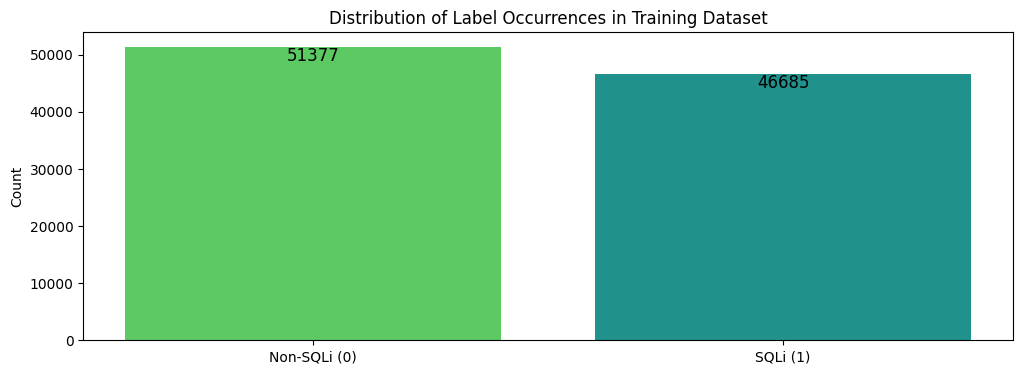

label
1    46685
0    51377
Name: count, dtype: int64


In [301]:
# visualization of class distribution (SQLi vs non-SQLi) in the training dataset
plt.figure(figsize=(12, 4))

train_counts = train_df['label'].value_counts()
plt.bar(['Non-SQLi (0)', 'SQLi (1)'], train_counts.values, color=['#5dc963', '#21918c'])
plt.title('Distribution of Label Occurrences in Training Dataset')
plt.ylabel('Count')
plt.text(0, train_counts[0] + 50, str(train_counts[0]), ha='center', va='top', fontsize=12)
plt.text(1, train_counts[1] + 50, str(train_counts[1]), ha='center', va='top', fontsize=12)

plt.savefig('../results/traininglabel_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

label_counts = train_df['label'].value_counts().sort_values()
print(label_counts)

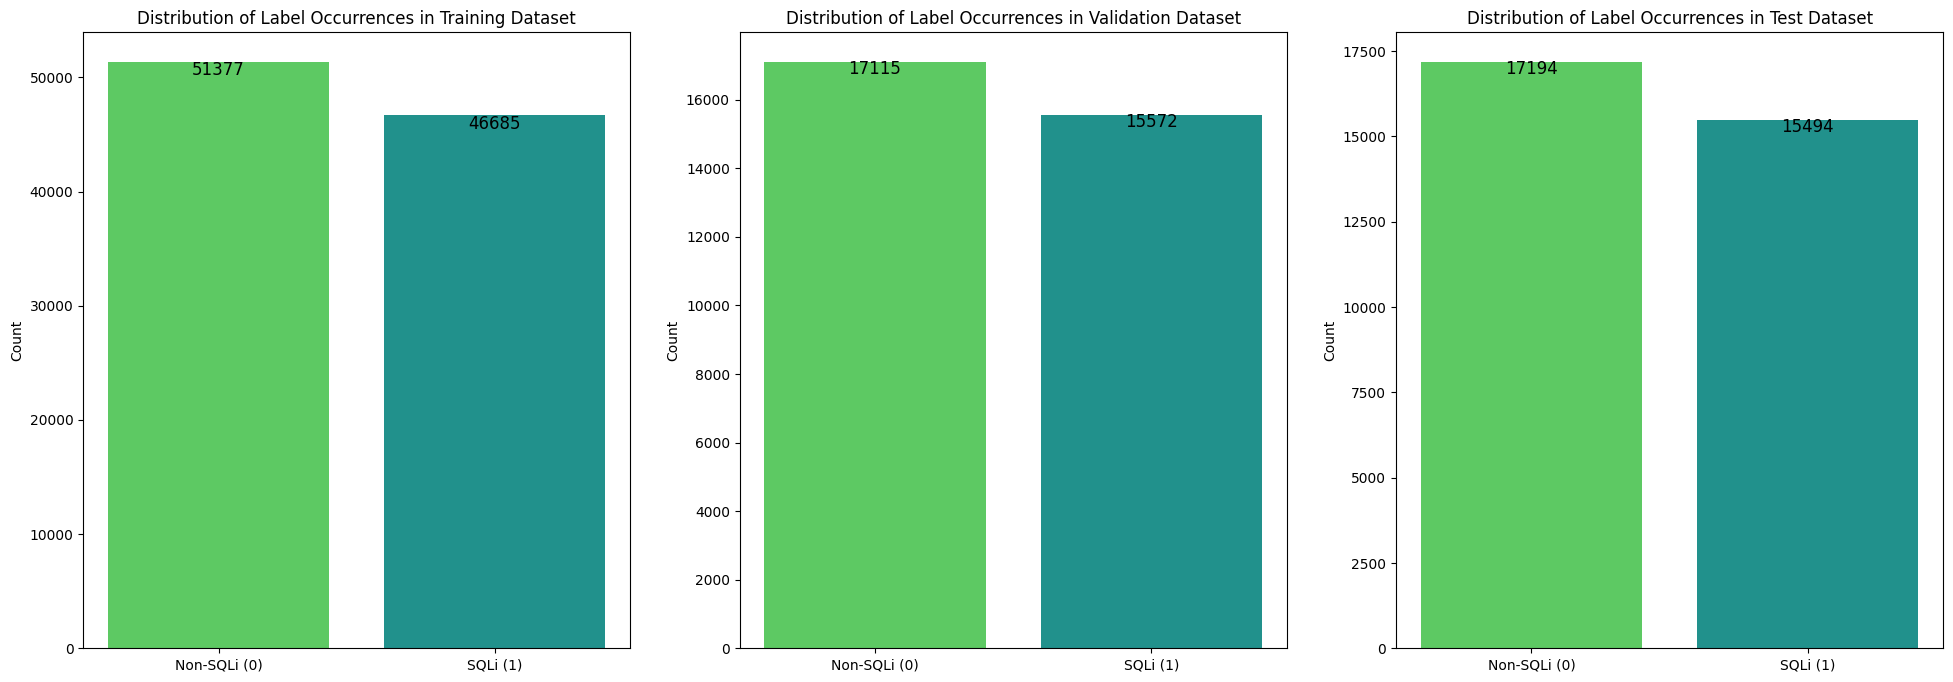

In [306]:
# visualization of class distribution (SQLi vs non-SQLi) in the training dataset
fig, ax = plt.subplots(1, 3, figsize=(24, 8))

train_counts = train_df['label'].value_counts()
val_counts = val_df['label'].value_counts()
test_counts = test_df['label'].value_counts()

ax[0].bar(['Non-SQLi (0)', 'SQLi (1)'], train_counts.values, color=['#5dc963', '#21918c'])
ax[0].set_title('Distribution of Label Occurrences in Training Dataset')
ax[0].set_ylabel('Count')
ax[0].text(0, train_counts[0] + 50, str(train_counts[0]), ha='center', va='top', fontsize=12)
ax[0].text(1, train_counts[1] + 50, str(train_counts[1]), ha='center', va='top', fontsize=12)

ax[1].bar(['Non-SQLi (0)', 'SQLi (1)'], val_counts.values, color=['#5dc963', '#21918c'])
ax[1].set_title('Distribution of Label Occurrences in Validation Dataset')
ax[1].set_ylabel('Count')
ax[1].text(0, val_counts[0] + 50, str(val_counts[0]), ha='center', va='top', fontsize=12)
ax[1].text(1, val_counts[1] + 50, str(val_counts[1]), ha='center', va='top', fontsize=12)

ax[2].bar(['Non-SQLi (0)', 'SQLi (1)'], test_counts.values, color=['#5dc963', '#21918c'])
ax[2].set_title('Distribution of Label Occurrences in Test Dataset')
ax[2].set_ylabel('Count')
ax[2].text(0, test_counts[0] + 50, str(test_counts[0]), ha='center', va='top', fontsize=12)
ax[2].text(1, test_counts[1] + 50, str(test_counts[1]), ha='center', va='top', fontsize=12)

plt.savefig('../results/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#conversion of datasets to Hugging Face format for easier use with Trainer API
train_dataset = Dataset.from_pandas(train_df[['query', 'label']])
val_dataset = Dataset.from_pandas(val_df[['query', 'label']])
print(train_dataset)
print(val_dataset)

Dataset({
    features: ['query', 'label', '__index_level_0__'],
    num_rows: 98062
})
Dataset({
    features: ['query', 'label', '__index_level_0__'],
    num_rows: 32687
})


In [307]:
test_dataset = Dataset.from_pandas(test_df[['query', 'label']])
print(test_dataset)

Dataset({
    features: ['query', 'label', '__index_level_0__'],
    num_rows: 32688
})


In [261]:
#Example of tokenization using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
text = "admin' OR '1'='1"

# Tokenize and encode the text
encoding = tokenizer.encode(text)
print("Token IDs:", encoding)

# Convert token IDs back to tokens
tokens = tokenizer.convert_ids_to_tokens(encoding)
print("Tokens:", tokens)

Token IDs: [101, 8050, 7937, 112, 23066, 112, 122, 112, 134, 112, 122, 102]
Tokens: ['[CLS]', 'ad', '##min', "'", 'OR', "'", '1', "'", '=', "'", '1', '[SEP]']


What does BERT do?
BERT (Bi-directional Encoder Representation from Transforers - (Transformer***)) - open-source machine learning framework designed for natural language processing (NLP). So basically it can generate human like language and understand it.

So the Transformer***, in original architecture has bith encoders and decoders. The decision is to use encoder-only in BERT so the primary usage would be to understand input sentences like e.g. SQLi rather than generating output sentences.

Traditional lang. model process text inputs sequrntially (either going left->right or right->left), but this is a problem beacuse it limits the model's awareness to the immediate context preceding the target word. BERT uses a bi-directional approach, hence the name, where he considerts both the left and right context of words in sentence i.e. BERT looks at all the words simultaneously.

How to PRE-train BERT?
BERT undergoes Pre-training on LARGE amounts of data like our database, from unlabeled text to learn contextual embeddings.Our BERT will understnd context to recognize malicious intent beyond simple keyword matching.It will learn from captured syntax patterns to learn the difference, and classify whether it contains malicious patterns.

We do NOT re-train BERT from scratch, because this would require billions of tokens of text data and massive computational resources and time. We take the pre-trained BERT and fine-tune it on specific task, our SQLi injection.

So sequence of tokens are fed to the Transformer encoder. These tokens are first embedded into vectors and then processed in the neural network.The output is a sequence of vectors, each corresponding to an input token, providing contextualized representations.

SEQUENCE -> TOKENS -> FED TO TRANSFORMER ENCODER -> TOKENS CONVERTED INTO VECTORS -> VECTORS PROCESSED IN NEURAL NETWORK

Last Layer's   |||     |||      |||     |||     |||     |||     |||     |||     |||     
Hidden States   |  |||  |   |||  |  |||  |  |||  |  |||  |  |||  |  |||  |  |||  |
                |   |   |    |   |   |   |   |   |   |   |   |   |   |   |   |   |   
|-----------------------------------------------------------------------------------|
|                                                                                   |
|                            BERT = Transformer Encoder                             |
|                                                                                   | 
|-----------------------------------------------------------------------------------|
               |       |       |     |     |     |    |    |    |    |    |     |
Token IDs: [  101,   8050,   7937,  112, 23066, 112, 122, 112, 134, 112, 122,  102  ]
Tokens:    ['[CLS]', 'ad', '##min', "'", 'OR', "'", '1', "'", '=', "'", '1', '[SEP]']

BERT Architecture
The architecture is a multilazer bidirectional transformer encoder which is quite similar to the transformer model, it has 2 main architectures. BERT(BASE) has 12 layers in the Encoder stack while BERT(LARGE) has 24 layers in the Encoder stack. BERT architectures(BASE and LARGE) also have larger feedforward network between 768 and 1024 hidden units, attention heads between 12 and 16.BERT(BASE) contains 110M parameters while BERT(LARGE) has 340M parameters.

The model takes the CLS toekn as input first, then it is followed by a sequence of words as input.CLS stands for classification token.It then passes the input to the above layers. Each layer applies self-attention and passes the result through a feedforward network and then gets hand over to the next encoder.The model then outputs a vector of hidden size(around 768 for BERT(BASE)).Now this trained VECTOR can be used to perform a number of tasks such as classification, translation, etc.



In [262]:
# Token and Encode Function
def tokenize_and_encode(tokenizer, comments, labels, truncation=True, max_length=128):
    # Tokenize and encode the comment using the BERT tokenizer
    encoded = tokenizer.batch_encode_plus(
            #list of all querries
            comments,
            # Add special tokens like [CLS] and [SEP]
            add_special_tokens=True,
            # Truncate or pad the comment to 'max_length'
            max_length=max_length,
            # Pad the comment to 'max_length' with zeros if needed
            padding='max_length',
            truncation=True,
            # Return attention mask to mask padded tokens
            return_attention_mask=True,
            # Return PyTorch tensors
            return_tensors='pt'
        )

    # Append the tokenized input and attention mask to their respective lists
    input_ids = encoded['input_ids']
    attention_masks = encoded['attention_mask']
    # Convert the labels to a PyTorch tensor with the data type long(64)
    labels = torch.tensor(labels, dtype=torch.long)

    # Return the tokenized inputs, attention masks, and labels as PyTorch tensors
    return input_ids, attention_masks, labels

In [263]:
#Token initialization
tokenizer = BertTokenizer.from_pretrained('bert-base-cased', do_lower_case=True)

In [264]:
#Model initialization
model = BertForSequenceClassification.from_pretrained('bert-base-cased', num_labels=2)
#if GPU is available, move the model to GPU, else we will use MPS (Metal Performance Shaders) for Apple Silicon devices, and if neither is available, we will use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)

print(f"Model loaded on device: {device}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on device: mps


In [265]:
#Initalizing train_df to 5000 samples for first training and testing

#train_df = train_df.sample(5000, random_state=42) #random state for reproducibility
#print("Training comments:", train_df.shape)

In [266]:
train_input_ids, train_attention_masks, train_labels = tokenize_and_encode(
    tokenizer=tokenizer,
    comments=train_df['query'].tolist(),
    labels=train_df['label'].tolist(),
    truncation=True,
    max_length=256
)

val_input_ids, val_attention_masks, val_labels = tokenize_and_encode(
    tokenizer=tokenizer,
    comments=val_df['query'].tolist(),
    labels=val_df['label'].tolist(),
    truncation=True,
    max_length=256
)

print("Training comments:", train_df.shape)
print("Training input ids:", train_input_ids.shape)
print("Training attention masks:", train_attention_masks.shape)
print("Training labels:", train_labels.shape)

print("Validation comments:", val_df.shape)
print("Validation input ids:", val_input_ids.shape)
print("Validation attention masks:", val_attention_masks.shape)
print("Validation labels:", val_labels.shape)


Training comments: (98062, 2)
Training input ids: torch.Size([98062, 256])
Training attention masks: torch.Size([98062, 256])
Training labels: torch.Size([98062])
Validation comments: (32687, 2)
Validation input ids: torch.Size([32687, 256])
Validation attention masks: torch.Size([32687, 256])
Validation labels: torch.Size([32687])


In [308]:
test_input_ids, test_attention_masks, test_labels = tokenize_and_encode(
    tokenizer=tokenizer,
    comments=test_df['query'].tolist(),
    labels=test_df['label'].tolist(),
    truncation=True,
    max_length=256
)
print("Test comments:", test_df.shape)
print("Test input ids:", test_input_ids.shape)
print("Test attention masks:", test_attention_masks.shape)
print("Test labels:", test_labels.shape)

Test comments: (32688, 2)
Test input ids: torch.Size([32688, 256])
Test attention masks: torch.Size([32688, 256])
Test labels: torch.Size([32688])


We have 98062 SQL querrys in training set and 32687 SQL querrys in validation set. Each querry is converted in 256 tokens. Short querrys are PAD-ed until 256 and longer are truncated on 256. With attention mask we can say to BERT wich tokens should he read(so with 1 BERT pays attention, and with 0 he ignores it). Beacuse most querrys are shorter its decides to put the max_lenght to be 256, beacuse for sql dataset it is a little overkill.If we went with 512 to combine with the big ones it would be 2x slower and i would take 2x more CPU resources. 

Mabye we can use make a test bench later to see if BERT would indentifz better if we used 512 token lenght.?????

In [267]:
train_df = train_df.reset_index(drop=True) #fixing gap hole in index after sampling

print('Training Comments -->',train_df.loc[3]) #or iloc so we dont use again reset_index
print('\nInput Ids -->\n',train_input_ids[3])
print('\nDecoded Ids -->\n',tokenizer.decode(train_input_ids[3]))
print('\nAttention Mask -->\n',train_attention_masks[3])
print('\nLabels -->',train_labels[3])

Training Comments --> query    jk dv1z0r39am1wjiiumia9xrxdowuo87f 110dcc d0ej...
label                                                    1
Name: 3, dtype: object

Input Ids -->
 tensor([  101,   179,  1377,   173,  1964,  1475,  1584,  1568,  1197, 24786,
         2312,  1475,  2246,  3454,  3656,  1465,  1580,  1775,  1197,  1775,
         2572, 20236,  1186,  1604,  1559,  2087,  6745,  1181, 19515,   173,
         1568, 21024,  1179, 26303,  1477,  1643,  1403,  1775,   176,  1181,
        27347, 10493,  1775,  1477,  1830,  1643,  1181,  6112,  1495,  2087,
         5084,  1571,  1179,  1477,  1182,  1183,  3361,  1604,  3361,  1604,
        28101,  2312,  1204,  1495,  1306, 17653,   128,  1161,  1604,  1161,
         1477,  1377,  1775,  4426,  1545,  1181,  1559,  1477,  1306,   124,
          175,  1559,  1204,  1179,  1559,  1580,  1571,  1179,  1495,  1183,
         1495,  3293,  1495,  1197,  1580,  1181,  1775,  2246,  1324,  3361,
        17653, 15184,  1183,  2087,  4043

In [268]:
#Creating pytorch data loaders for training and validation datasets
batch_size = 32
train_dataset = TensorDataset(train_input_ids, train_attention_masks, train_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_input_ids, val_attention_masks, val_labels)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [309]:
batch_size = 32
test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_labels)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [269]:
#with shuffle=True every time we have new batch of data, so we can see different examples in each epoch
print('Batch Size :',train_loader.batch_size)
Batch =next(iter(train_loader)) #returns a batch of data from the train_loader, which is an iterator that yields batches of data. The next() function retrieves the next batch from the iterator.
print('Each Input ids shape :',Batch[0].shape)
print('Input ids :\n',Batch[0][0]) 
print('Corresponding Decoded text:\n',tokenizer.decode(Batch[0][0])) #we get first query from the batch and decode it to see the original text
print('Corresponding Attention Mask :\n',Batch[1][0])
print('Corresponding Label:',Batch[2][0])


Batch Size : 32
Each Input ids shape : torch.Size([32, 256])
Input ids :
 tensor([  101,   122,  1187,  6332,   134,  6332,  3779,  1155,  8247, 26280,
          117, 26280,   117, 26280,   117, 26280,   117, 26280,   117, 26280,
          117, 26280,   117, 26280,   117, 26280,   118,   118,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     

In [270]:
#initializating the optimizer for training the model - standard procedure
#we are going to try to use the AdamW optimiyer, which refers to Adaptive Moment Estimation.Basically it combines
#the advantages of both the RMSprop(Root Mean Square Propagation) and AdaGrad(Adaptive Gradient Algorithm)


#for each model parameter, it includes moving avarages of the gradient and the squared gradient, which helps in adjusting the
#learning rate for various parameters during training

optimizer = AdamW(model.parameters(), lr=2e-5)

In [271]:
#Training model
import time

def time_format(seconds):
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}m {seconds:.2f}s"

def train_model(model,train_loader, optimizer, device, num_epochs):
    train_losses = []
    val_loses = []
    #We are looping thru given number of epochs
    for epoch in range(num_epochs):
        start_time = time.time() #measuring time for each epoch on 'mps' device

        #set the model to training
        model.train()

        #for each epoch we initaliye total_loss
        total_loss = 0

        #looping thru batches of data from the train_loader
        for batch in train_loader:
            #model and data need to be on same device aka in our case on CPU
            train_input_ids, train_attention_masks, train_labels = [t.to(device) for t in batch] #this line unpacks the batch that consists of 3 tensors, and packs then in own varaibles, and its sending them to the cpu
            optimizer.zero_grad() #we need to zero the gradients before each backward pass, otherwise they will accumulate

            outputs = model(input_ids=train_input_ids, attention_mask=train_attention_masks, labels=train_labels) #forward pass - we are passing the input ids, attention masks and labels to the model, and it will return the output which contains the loss and logits
            loss = outputs.loss #we are getting the loss from the output
            total_loss += loss.item() #we are adding the loss to the total loss for the
            loss.backward() #backward pass - we are calculating the gradients
            optimizer.step() #we are updating the model parameters based on the calculated gradients
        
        model.eval() #after each epoch we are setting the model to evaluation mode
        val_loss = 0
        
        with torch.no_grad(): #we are not calculating gradients during evaluation
            for batch in val_loader:
                train_input_ids, train_attention_masks, train_labels = [t.to(device) for t in batch] #setting to the same device

                outputs = model(input_ids=train_input_ids, attention_mask=train_attention_masks, labels=train_labels) #forward pass
                loss = outputs.loss #getting the loss
                val_loss += loss.item() #adding the loss to the total validation loss

        #printing average loss for the current epoch
        avg_train_loss = total_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_loses.append(avg_val_loss)

        print(f"Epoch {epoch+1}, Training Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}, Time: {time_format(time.time() - start_time)}")

    return train_losses, val_loses

#Moment of truth - we are going to train the model for 3 epochs and see how it performs

#train_model(model, train_loader, optimizer, device, num_epochs=1)
#train_losses, val_losses = train_model(model, train_loader, optimizer, device, num_epochs=1) #Epoch 1, Training Loss: 0.017636024737196745, Validation Loss: 0.0207665073122636
#train_losses, val_losses = train_model(model, train_loader, optimizer, device, num_epochs=3) 
                                                                                                #Epoch 1, Training Loss: 0.09553611398360153, Validation Loss: 0.01987610054598782, Time: 6m 11.08s
                                                                                                #Epoch 2, Training Loss: 0.01912913777476924, Validation Loss: 0.016973818425880107, Time: 6m 11.48s
                                                                                                #Epoch 3, Training Loss: 0.007968699619630766, Validation Loss: 0.017064841367225043, Time: 6m 11.24s
#full dataset training on 4 epohs
train_losses, val_losses = train_model(model, train_loader, optimizer, device, num_epochs=4)                                                                                               

Epoch 1, Training Loss: 0.017298108357549438, Validation Loss: 0.009088274127381396, Time: 50m 25.09s
Epoch 2, Training Loss: 0.008843207211001937, Validation Loss: 0.00913099885928224, Time: 50m 11.91s
Epoch 3, Training Loss: 0.005835668374152897, Validation Loss: 0.009297386203853116, Time: 50m 13.81s
Epoch 4, Training Loss: 0.005655362686402931, Validation Loss: 0.008406350389233312, Time: 50m 12.28s


Our Loss if very good! With:
Epoch 1, Training Loss: 0.017298108357549438, Validation Loss: 0.009088274127381396, Time: 50m 25.09s
Epoch 2, Training Loss: 0.008843207211001937, Validation Loss: 0.00913099885928224, Time: 50m 11.91s
Epoch 3, Training Loss: 0.005835668374152897, Validation Loss: 0.009297386203853116, Time: 50m 13.81s
Epoch 4, Training Loss: 0.005655362686402931, Validation Loss: 0.008406350389233312, Time: 50m 12.28s

Validation set of 0.0084 loos is exteremly low, we can say that the model almost perfectly classifies SQLi vs nonSQLi injections!

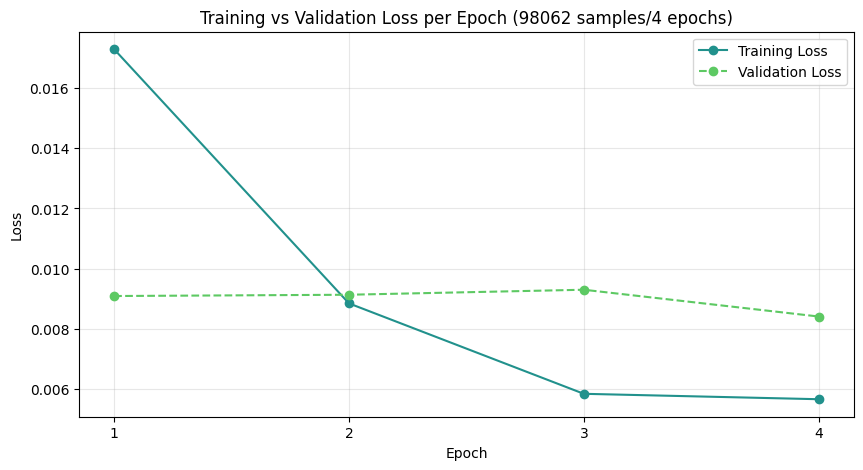

In [277]:
# Visualization of training vs validation loss - checking for overfitting
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'o-', color='#21918c', label='Training Loss')
plt.plot(epochs, val_losses, 'o--', color='#5dc963', label='Validation Loss')
plt.title('Training vs Validation Loss per Epoch (98062 samples/4 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.savefig('../results/loss_curve_4epochs.png', dpi=300, bbox_inches='tight')
plt.show()

In [336]:
#evaluating the model on the testing set after training
def evaluate_model(model, test_loader, device):
    model.eval() #setting the model to evaluation mode
    
    true_labels = []
    predicted_probs = []

    with torch.no_grad(): #we are not calculating gradients during evaluation
        for batch in test_loader:
            test_input_ids, test_attention_masks, test_labels = [t.to(device) for t in batch] #setting to the same device

            #getting the models predictions for the validation set
            outputs = model(input_ids=test_input_ids, attention_mask=test_attention_masks) #forward pass - we are passing the input ids and attention masks to the model, and it will return the output which contains the logits
            
            #we are using argmax for multilabel classification - 
            #predicted_probs_batch = torch.argmax(outputs.logits, dim=1)
            predicted_probs_batch = torch.softmax(outputs.logits, dim=1)
            predicted_probs.append(predicted_probs_batch.cpu().numpy()) #we are moving the predicted probabilities to cpu and converting them to numpy array, and appending them to the list of predicted probabilities
            
            true_labels_batch = test_labels.cpu().numpy() #we are moving the true labels to cpu and converting them to numpy array
            true_labels.append(true_labels_batch) #we are appending the true labels to the list
    
    #now we are combining preedictions and labels for evaluation
    true_labels = np.concatenate(true_labels, axis=0) #we are concatenating the list of true labels into a single numpy array
    predicted_probs = np.concatenate(predicted_probs, axis=0) #we are concatenating

    #predicted_labels = (predicted_probs > 0.5).astype(int) #argmax
    #softmax - 0.3 thershold - take all rows only one column
    #predicted_labels = (predicted_probs[:,1] > 0.2).astype(int) #we are converting the predicted probabilities to binary labels using a threshold of 0.2
    predicted_labels = (predicted_probs[:,1] > 0.3).astype(int) #we are converting the predicted probabilities to binary labels using a threshold of 0.3
    #predicted_labels = (predicted_probs[:,1] > 0.5).astype(int) #we are converting the predicted probabilities to binary labels using a threshold of 0.5

    #calculating evaluations metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='binary')
    recall = recall_score(true_labels, predicted_labels, average='binary')
    f1 = f1_score(true_labels, predicted_labels, average='binary')

    #priniting the evaluation results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return true_labels, predicted_labels


#the function call for evaluating model -(98062 samples/4 epochs)
true_labels, predicted_labels = evaluate_model(model, test_loader, device)

Accuracy: 0.9983
Precision: 0.9981
Recall: 0.9983
F1 Score: 0.9982


With argmax on 0.5 threshold:
With a test set of 32,688 samples, the model made errors on only ~65 samples. Precision of 99.83% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.75% means it catches nearly all real SQLi attacks. F1 score of 99.79% confirms a perfect balance between precision and recall.

With softmax 0n 0.3 threshold:
With a test set of 32,688 samples, the model made errors on only ~57 samples. Precision of 99.81% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.83% means it catches nearly all real SQLi attacks. F1 score of 99.82% confirms a perfect balance between precision and recall.

With softmax on 0.5 threshold - same as argmax 0.5 threshold:
With a test set of 32,688 samples, the model made errors on only ~65 samples. Precision of 99.83% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.75% means it catches nearly all real SQLi attacks. F1 score of 99.79% confirms a perfect balance between precision and recall.

With softmax on 0.2 threshold:
With a test set of 32,688 samples, the model made errors on only ~56 samples. Precision of 99.79% means that when the model flags a query as SQLi, it is almost always correct. Recall of 99.85% means it catches nearly all real SQLi attacks. F1 score of 99.82% confirms a perfect balance between precision and recall.

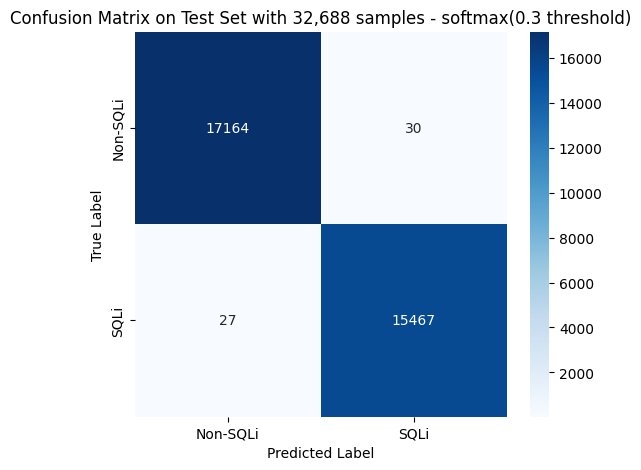

In [339]:
#visualising the confusion matrix for the test set
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-SQLi', 'SQLi'], yticklabels=['Non-SQLi', 'SQLi'])
plt.title('Confusion Matrix on Test Set with 32,688 samples - softmax(0.3 threshold)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('../results/confusion_matrix_on_test_softmax_0_3.png', dpi=300, bbox_inches='tight')
plt.show()

On argmax with 0.5 threshold: 
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 26 - legitimate queries that were incorrectly classified as SQLi
(FN) - 38 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
38/15456 = 0.00245859
1/0.00245 = 408 -> so if 0.245% attacs are passing, only 1 in 408 attacs

On softmax with 0.3 threshold:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 30 - legitimate queries that were incorrectly classified as SQLi
(FN) - 27 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
27/15456 = 0.00174565
1/0.00174 = 572 -> so if 0.174% attacs are passing, only 1 in 572 attacs

On softmax with 0.5 threshold:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 26 - legitimate queries that were incorrectly classified as SQLi
(FN) - 38 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
38/15456 = 0.00245859
1/0.00245 = 408 -> so if 0.245% attacs are passing, only 1 in 408 attacs

On softmax with 0.2 threshold:
(TN) - 17168 - legitimate queries that were correctly classified as non-SQLi
(FP) - 32 - legitimate queries that were incorrectly classified as SQLi
(FN) - 24 - missed SQLi 
(TP) - 15456 - SQLi queries that were correctly classified as SQLi

So we can say in every ~400 attacs only 1 injection is passing
24/15456 = 0.0015528
1/0.00155 = 408 -> so if 0.155% attacs are passing, only 1 in 645 attacs